In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
MAX_FEATURES =500
# Load the images
img1 = cv2.imread('apple-color.jpg', cv2.COLOR_BGR2GRAY)
img2 = cv2.imread('apple-color2.jpg', cv2.COLOR_BGR2GRAY)
img2normal = cv2.imread('apple-color2.jpg')



Image alignment


In [ ]:
# Initialize ORB detector
orb = cv2.ORB_create(MAX_FEATURES)

# Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

GOOD_MATCH_PERCENT = 30

# Match features using bruteforce
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(des1, des2, None))

# Sort matches by score
matches.sort(key=lambda x: x.distance, reverse=False)

numGoodMatches = int(len(matches) * GOOD_MATCH_PERCENT)
matches = matches[:numGoodMatches]

print(matches)


# Draw top matches
imMatches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None)
cv2.imwrite("matches.jpg", imMatches)

# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = kp1[match.queryIdx].pt
    points2[i, :] = kp2[match.trainIdx].pt

[< cv2.DMatch 0x7f257c7f41b0>, < cv2.DMatch 0x7f257c7f4590>, < cv2.DMatch 0x7f257c7f4a30>, < cv2.DMatch 0x7f257c7f4d50>, < cv2.DMatch 0x7f257c7f4a50>, < cv2.DMatch 0x7f257c7f4d70>, < cv2.DMatch 0x7f257c7f4bf0>, < cv2.DMatch 0x7f257c7f4bd0>, < cv2.DMatch 0x7f257c7f4f10>, < cv2.DMatch 0x7f257c7f50f0>, < cv2.DMatch 0x7f257c7f4730>, < cv2.DMatch 0x7f257c7f4f30>, < cv2.DMatch 0x7f257c7f52b0>, < cv2.DMatch 0x7f257c7f5450>, < cv2.DMatch 0x7f257c7f4a70>, < cv2.DMatch 0x7f257c7f4d90>, < cv2.DMatch 0x7f257c7f4f50>, < cv2.DMatch 0x7f257c7f5110>, < cv2.DMatch 0x7f257c7f5290>, < cv2.DMatch 0x7f257c7f50d0>, < cv2.DMatch 0x7f257c7f52d0>, < cv2.DMatch 0x7f257c7f5470>, < cv2.DMatch 0x7f257c7f4df0>, < cv2.DMatch 0x7f257c7f5170>, < cv2.DMatch 0x7f257c7f4950>, < cv2.DMatch 0x7f257c7f51d0>, < cv2.DMatch 0x7f257c7f4fb0>, < cv2.DMatch 0x7f257c7f4ad0>, < cv2.DMatch 0x7f257c7f4c50>, < cv2.DMatch 0x7f257c7f5030>, < cv2.DMatch 0x7f257c7f5050>, < cv2.DMatch 0x7f257c7f51f0>, < cv2.DMatch 0x7f257c7f5210>, < cv2.DMa

In [ ]:
print(points1[:5])
print("debug--------------------------")
print(points2[:5])

[[459.      303.     ]
 [462.      304.     ]
 [458.40002 302.40002]
 [457.92004 302.40002]
 [462.00003 303.6    ]]
debug--------------------------
[[361. 429.]
 [362. 426.]
 [361. 429.]
 [361. 429.]
 [362. 426.]]


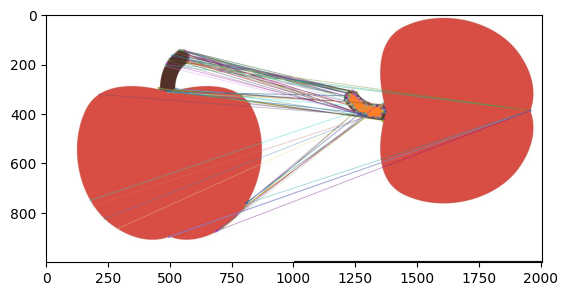

In [ ]:
# Display image
imgmatched = plt.imread("matches.jpg")
plt.imshow(imgmatched)

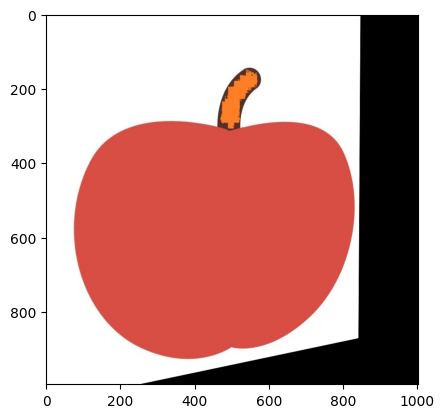

In [ ]:
# Apply image transformation
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)
height, width, channels = img2.shape
im1Reg = cv2.warpPerspective(img2normal, h, (width, height))
cv2.imwrite("imgrewrite.jpg", im1Reg)
imgshow = plt.imread("imgrewrite.jpg")
plt.imshow(imgshow)

[< cv2.DMatch 0x7f258cfed890>, < cv2.DMatch 0x7f258cfed590>, < cv2.DMatch 0x7f258cfedf30>, < cv2.DMatch 0x7f257c438070>, < cv2.DMatch 0x7f257c439610>, < cv2.DMatch 0x7f257c4392f0>, < cv2.DMatch 0x7f257c43ba70>, < cv2.DMatch 0x7f257c43b070>, < cv2.DMatch 0x7f257c43bc30>, < cv2.DMatch 0x7f257c438a70>, < cv2.DMatch 0x7f257c438830>, < cv2.DMatch 0x7f257c439150>, < cv2.DMatch 0x7f257c43a710>, < cv2.DMatch 0x7f257c43b270>, < cv2.DMatch 0x7f257c439810>, < cv2.DMatch 0x7f257c438f30>, < cv2.DMatch 0x7f257c4389b0>, < cv2.DMatch 0x7f257c4399b0>, < cv2.DMatch 0x7f257c43a930>, < cv2.DMatch 0x7f257c43b4f0>, < cv2.DMatch 0x7f257c439af0>, < cv2.DMatch 0x7f257c43b630>, < cv2.DMatch 0x7f257c439390>]


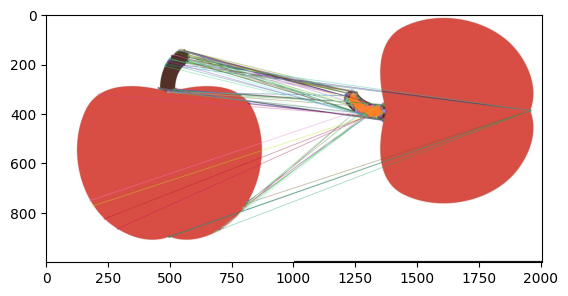

In [ ]:
# KNN matching solution

matcherv2 = cv2.BFMatcher(cv2.NORM_HAMMING2)
matcher2S = matcherv2.knnMatch(des1, des2, k=2)
ratio = 0,75 # extract only 75% neighbor

# Apply Lowe's ratio test with 0.75 threshold
matcher2SResult = []
for m, n in matcher2S:
    if m.distance < 0.75 * n.distance:
        matcher2SResult.append(m)

print(matcher2SResult)


# Draw top matches
imMatches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None)
cv2.imwrite("matches2.jpg", imMatches)

imgmatchedSensei = plt.imread("matches2.jpg")
plt.imshow(imgmatchedSensei)


6
89
80
252
308
Stitched image saved to stitched_output.jpg


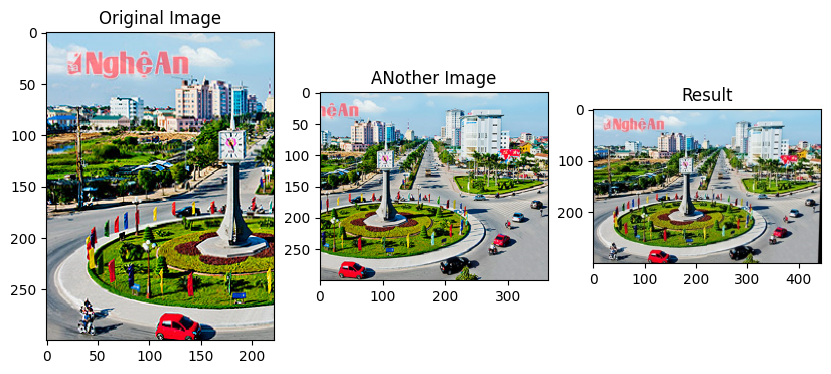

In [ ]:
import cv2
import numpy as np

def stitch_images(image1_path, image2_path, output_path):
    # Load the images
    img1 = cv2.imread(image1_path)
    img2 = cv2.imread(image2_path)

    # Convert images to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Detect ORB keypoints and descriptors
    orb = cv2.ORB_create()
    keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)

    # Match descriptors using the BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matchesIMGStich = bf.match(descriptors1, descriptors2)

    # Sort matches by distance
    matchesIMGStich = sorted(matchesIMGStich, key=lambda x: x.distance)

    for i in range (5) :
        print(matchesIMGStich[i].queryIdx)

    # Extract location of good matches
    points1 = np.zeros((len(matchesIMGStich), 2), dtype=np.float32)
    points2 = np.zeros((len(matchesIMGStich), 2), dtype=np.float32)

    for i, match in enumerate(matchesIMGStich):
        points1[i, :] = keypoints1[match.queryIdx].pt
        points2[i, :] = keypoints2[match.trainIdx].pt

    # Find homography
    h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

    # Warp image2 to image1's plane
    height, width, channels = img1.shape
    img2_warped = cv2.warpPerspective(img2, h, (width * 2, height))

    # Place image1 in the stitched image
    img2_warped[0:height, 0:width] = img1

    # Save the stitched image
    cv2.imwrite(output_path, img2_warped)
    print(f"Stitched image saved to {output_path}")



def stitch_imagesVer2(image1_path, image2_path, output_path):
    percentMatchKnn = 0.75
    # Load the images
    img1 = cv2.imread(image1_path)
    img2 = cv2.imread(image2_path)

    if img1 is None or img2 is None:
        raise FileNotFoundError("One or both image paths are incorrect or the files do not exist.")

    # Convert images to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Detect ORB keypoints and descriptors
    orb = cv2.ORB_create()
    keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)

    # KNN matching with Lowe's ratio test
    bf = cv2.BFMatcher(cv2.NORM_HAMMING2)
    knn_matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    good_matches = []
    for m, n in knn_matches:
        if m.distance < percentMatchKnn * n.distance:
            good_matches.append(m)

    if len(good_matches) < 4:
        raise ValueError("Not enough good matches found to compute homography.")

    # Extract matched keypoints
    points1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
    points2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

    # Compute homography
    h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

    # Warp image2 to image1's plane
    height, width, _ = img1.shape
    img2_warped = cv2.warpPerspective(img2, h, (width * 2, height))

    # Place image1 in the stitched image
    img2_warped[0:height, 0:width] = img1

    # Save the stitched image
    cv2.imwrite(output_path, img2_warped)
    print(f"Stitched image saved to {output_path}")


# Replace 'placeholder1.jpg' and 'placeholder2.jpg' with your actual image paths
stitch_images('ngheAnP1.png', 'ngheAnP2.png', 'stitched_output.jpg')

#show all 3 image using plt
imgInput1 = plt.imread('ngheAnP1.png')
imgInput2 = plt.imread('ngheAnP2.png')
imgSumUp = plt.imread('stitched_output.jpg')


plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(imgInput1)
plt.title("Original Image")
plt.subplot(1, 3, 2)
plt.imshow(imgInput2)
plt.title(f"ANother Image")
plt.subplot(1, 3, 3)
plt.imshow(imgSumUp)
plt.title(f"Result")
plt.show()